# HR Recruitment Funnel Analysis
### Project Overview

This project analyzes the end-to-end recruitment process to understand candidate movement across hiring stages and identify inefficiencies in the recruitment pipeline.

This project demonstrates end-to-end data analytics workflow including:

- Azure Data Engineering (Blob Storage, Azure Data Factory, Azure SQL)
- SQL Data Cleaning and Transformation
- Python Data Analysis
- Exploratory Data Analysis (EDA)
- Business Insights and Recommendations

---

### Problem Statement

Organizations invest significant time and resources in hiring talent, but without structured analysis, HR teams lack visibility into:

- How candidates progress through recruitment stages
- Where the highest drop-offs occur
- Overall hiring conversion efficiency
- Offer acceptance performance

This project aims to analyze recruitment data to measure stage-wise candidate conversion, hiring rate, and drop-offs, and provide data-driven insights and recommendations to optimize the recruitment process.


### Key Business Questions

This analysis answers the following business questions:

1. How many candidates progress through each stage of the recruitment funnel?
2. At which stage do we lose the most candidates?
3. What is the stage-to-stage conversion rate?
4. How effective is the screening process?
5. What is the offer acceptance rate?
6. Which recruitment sources yield the highest number of successful hires?
7. Are there significant drop-offs at specific stages that require process optimization?
----



### Tools & Technologies Used

• Azure Blob Storage  
• Azure Data Factory  
• Azure SQL Database  
• SQL Server Management Studio (SSMS)  
• Python  
• Pandas  
• Matplotlib 
• Plotly
• Seaborn

---

### Data Source

The data was ingested from Azure Blob Storage into Azure SQL Database using Azure Data Factory pipelines and cleaned using SQL queries.

### Import Required Libraries

In [1]:
# Data manipulation library
import pandas as pd

# Numerical library
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Database connection libraries
from sqlalchemy import create_engine
import urllib
import os
from dotenv import load_dotenv

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load environment variables from .env file
load_dotenv()

# Set visualization style
sns.set_theme(style='whitegrid')

# Display all columns
pd.set_option('display.max_columns', None)


### Connect to Azure Sql Database to Python Pandas

In this step, we establish a secure connection to Azure SQL Database using PyODBC.

In [2]:
# Create a connection engine to Azure SQL using credentials from .env
username = os.getenv("DB_USERNAME")
password = os.getenv("DB_PASSWORD")
server = os.getenv("DB_SERVER")
database = os.getenv("DB_NAME")

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Connection Timeout=90;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


### Load Data from Azure SQL


In [3]:
# SQL Query for Loading Data from Azure SQL Database
query = """
SELECT *
FROM HR_Recruitment
"""

# Load into pandas dataframe
df = pd.read_sql(query, engine)

# Show first 10 rows
df.head(10)


,CandidateID,PositionID,JobTitle,ApplicationDate,Source,Stage,DateatStage
0,CAND-1,POS-1,IT,2026-01-20,EMPLOYEE REFERRAL,APPLIED,2026-01-20
1,CAND-2,POS-1,IT,2026-01-20,JOB FAIR,SCREENED,2026-01-27
2,CAND-5,POS-1,IT,2025-11-22,EMPLOYEE REFERRAL,APPLIED,2025-11-22
3,CAND-6,POS-1,IT,2025-11-22,LINKEDIN,REJECTED,2025-11-28
4,CAND-9,POS-1,IT,2025-11-24,INDEED,INTERVIEW 1,2025-11-24
5,CAND-10,POS-1,IT,2025-11-16,JOB FAIR,INTERVIEW 2,2025-12-01
6,CAND-11,POS-1,IT,2025-11-16,EMPLOYEE REFERRAL,OFFER,2025-12-06
7,CAND-13,POS-1,IT,2025-10-24,EMPLOYEEREFERRAL,APPLIED,2025-10-24
8,CAND-14,POS-1,IT,2025-10-24,EMPLOYEEREFERRAL,UNKNOWN,2025-10-31
9,CAND-14,POS-1,IT,2025-10-24,EMPLOYEE REFERRAL,REJECTED,2025-10-31


### Data Overview

Understanding structure, shape, and data types of the data

In [4]:
# Shape of data
df.shape

(8452, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8452 entries, 0 to 8451
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CandidateID      8452 non-null   object
 1   PositionID       8452 non-null   object
 2   JobTitle         8452 non-null   object
 3   ApplicationDate  8452 non-null   object
 4   Source           8452 non-null   object
 5   Stage            8452 non-null   object
 6   DateatStage      8452 non-null   object
dtypes: object(7)
memory usage: 462.3+ KB


In [6]:
# Summary statistics
df.describe()

,CandidateID,PositionID,JobTitle,ApplicationDate,Source,Stage,DateatStage
count,8452,8452,8452,8452,8452,8452,8452
unique,7882,264,8,134,9,10,145
top,CAND-3662,POS-163,QC,2026-01-17,LINKEDIN,REJECTED,2026-01-29
freq,2,252,1954,178,1467,2060,150


### Standardizing Categorical Column Values

In [31]:
# List the tageted columns you want to standardize
category_col = ['Source', 'Stage', 'JobTitle']

# Checking unique values of each columns before cleaning
for col in category_col:
    print(f"Unique Values in the {col} column: {df[col].unique()}")

Unique Values in the Source column: ['Employee Referral' 'Job Fair' 'Linkedin' 'Indeed' 'Company Website'
 'Other']
Unique Values in the Stage column: ['Applied' 'Screened' 'Rejected' 'Interview 1' 'Interview 2' 'Offer'
 'Unknown' 'Hired' 'Interview1' 'Interview2']
Unique Values in the JobTitle column: ['IT' 'REGIONAL SALES' 'NOT SPECIFIED' 'RESEARCH' 'MARKETING' 'OPERATIONS'
 'QC' 'ACCOUNT']


In [32]:
# Fix the specific missing-space in the values of the specific column
# Standardize casing to Title Case 
df['Source']= df['Source'].replace({'EMPLOYEEREFERRAL': 'EMPLOYEE REFERRAL', 'JOBFAIR': 'JOB FAIR', 'COMPANYWEBSITE': 'COMPANY WEBSITE'}).str.title()

# Verifying changes made in source column
print(df['Source'].unique())

['Employee Referral' 'Job Fair' 'Linkedin' 'Indeed' 'Company Website'
 'Other']


In [33]:
# Fix the missing-space in the values of the specific column
# Standardize casing to Title Case 
df['Stage']= df['Stage'].replace({'Interview1': 'Interview 1', 'Interview2': 'Interview 2'}).str.title()

# Verifying changes
df['Stage'].unique()

array(['Applied', 'Screened', 'Rejected', 'Interview 1', 'Interview 2',
       'Offer', 'Unknown', 'Hired'], dtype=object)

### Converting Date Columns

In [34]:
# Convert date columns to Proper Datetime Format
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['DateatStage'] = pd.to_datetime(df['DateatStage'])

# verifying data types of each column after conversion
df.dtypes

CandidateID                object
PositionID                 object
JobTitle                   object
ApplicationDate    datetime64[ns]
Source                     object
Stage                      object
DateatStage        datetime64[ns]
TimeToStage                 int64
dtype: object

### Calculate Values for KPI

In [35]:
# Total unique applicants
total_applicants = df[~df['Stage'].isin(['Unknown', 'Rejected'])]['CandidateID'].nunique()

# Total unique hired candidates
total_hired = df[df['Stage'] == 'Hired']['CandidateID'].nunique()

# Hiring rate percentage
hiring_rate = (total_hired / total_applicants) * 100

print(hiring_rate)

7.4405921308920915


#### Total Applicants KPI


In [36]:
# Create Total Applicants KPI Card

fig = go.Figure(go.Indicator(
    mode="number",
    value=total_applicants,
    number={'valueformat': ','},
    title={"text": "Total Applicants"}
))

fig.update_layout(
    template="plotly_white",
    height=300
)

fig.show()

#### Total Hired Candidates KPI 

In [37]:
# Create Total Hired Applicants KPI Card

fig = go.Figure(go.Indicator(
    mode="number",
    value=total_hired,
    number={'valueformat': ','},
    title={"text": "Total Hired Candidates"}
))

fig.update_layout(
    template="plotly_white",
    height=300
)

fig.show()

#### Hiring Rate KPI

In [38]:
# Create Hiring Rate KPI Card

fig = go.Figure(go.Indicator(
    mode="number",
    value=round(hiring_rate, 2),
    number={'suffix': "%"},
    title={"text": "Hiring Rate"}
))

fig.update_layout(
    template="plotly_white",
    height=300
)

fig.show()

### Recruitment Funnel Analysis

Analyzing candidate progression through recruitment stages.

In [39]:
# Exclude Unknown and Rejected stages
funnel_counts = (
    df[~df['Stage'].isin(['Unknown', 'Rejected'])]   # remove these two
      ['Stage']
      .value_counts()
      .sort_values(ascending=False)
)

funnel_counts

Stage
Applied        1937
Screened       1230
Interview 1     836
Interview 2     642
Offer           418
Hired           398
Name: count, dtype: int64

In [40]:
# Prepare the data
# We ensure the stages are in the correct order for a funnel
stages = funnel_counts.index
counts = funnel_counts.values

# Create the interactive funnel chart
fig = px.funnel(
    data_frame=None, 
    x=counts, 
    y=stages,
    title="Recruitment Funnel",
    labels={'x': 'Number of Candidates', 'y': 'Stage'},
    color_discrete_sequence=px.colors.sequential.Blues_r
)

# Customize the layout
fig.update_traces(
    textinfo="percent initial", # Shows the number of candidates in % of each recruitment stage
    marker_line_width=2,
    marker_line_color="white"
)

fig.update_layout(
    title_x=0.5, # Centers the title
    template="plotly_white",
    yaxis_title=None # Removes redundant 'Stage' label to look cleaner
)

# 4. Display the chart
fig.show()

**Data Insights**

- **High Drop-off at Screening:** Significant reduction in candidates from the **Applied (1,937)** to **Screened (1,230)** stage, highlighting a **strict initial filtering** process.
- **Strong Offer Acceptance:** The conversion from **Offer (418)** to **Hired (398)** is exceptionally high (**95%**), indicating that candidates who reach the final stage **find the roles and offers highly appealing**.
- **Consistent Pipeline:** The progression from **Interview 1 (836)** to **Interview 2 (642)** demonstrates a steady and controlled candidate flow.
---

### Source Effectiveness Analysis

This analysis evaluates which recruitment sources produce the highest number of hired candidates.


In [41]:
# We analyze only candidates who reached the **Hired** stage.
hired = df[df['Stage'] == 'Hired']

# Count hires by source
source_hired = hired['Source'].value_counts()

# Display results
source_hired

Source
Job Fair             80
Linkedin             77
Indeed               73
Company Website      65
Employee Referral    58
Other                45
Name: count, dtype: int64

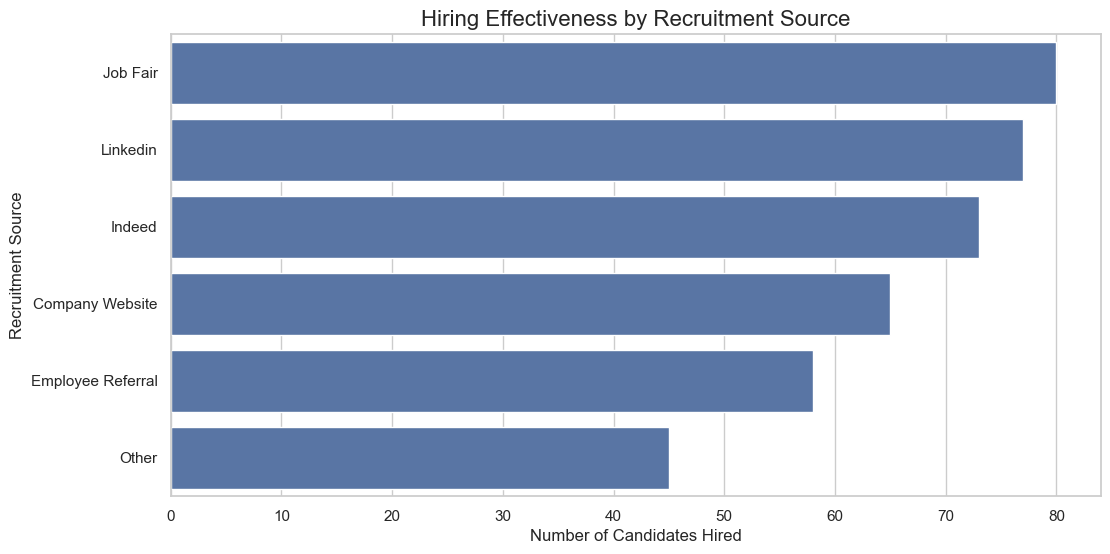

In [42]:
# Visualization: Hiring Effectiveness by Source
plt.figure(figsize=(12,6))

sns.barplot(
    x=source_hired.values,
    y=source_hired.index
)

plt.title("Hiring Effectiveness by Recruitment Source", fontsize=16)
plt.xlabel("Number of Candidates Hired", fontsize=12)
plt.ylabel("Recruitment Source", fontsize=12)

plt.show()

**Data Insights**
- **Job Fairs** generated the **highest hires (80)**, showing that **in-person events** are your most **effective hiring source**.

- **LinkedIn** brought the **most applications (1,467)** and **77 hires**, making it a **strong platform** for attracting **large numbers of candidates**.

- **Company website** and **employee referrals** together produced **123 hires**, proving **internal channels are highly effective** in finding suitable talent.

### Time to Hire Analysis

This analysis measures the average time taken to move candidates from application to hiring and identifies delays in the recruitment process.

In [43]:
# Calculate time difference
df['TimeToStage'] = (df['DateatStage'] - df['ApplicationDate']).dt.days

# Display first few rows to verify calculation
df.head()

,CandidateID,PositionID,JobTitle,ApplicationDate,Source,Stage,DateatStage,TimeToStage
0,CAND-1,POS-1,IT,2026-01-20,Employee Referral,Applied,2026-01-20,0
1,CAND-2,POS-1,IT,2026-01-20,Job Fair,Screened,2026-01-27,7
2,CAND-5,POS-1,IT,2025-11-22,Employee Referral,Applied,2025-11-22,0
3,CAND-6,POS-1,IT,2025-11-22,Linkedin,Rejected,2025-11-28,6
4,CAND-9,POS-1,IT,2025-11-24,Indeed,Interview 1,2025-11-24,0


In [44]:
# Calculate average time taken for each hiring stage

avg_time_stage = (
    df.groupby('Stage')['TimeToStage']
      .mean()
      .round()
      .reset_index()
      .sort_values('TimeToStage')
)

# Filter: Keep all stages EXCEPT 'Applied' and 'Unknown'
avg_time_stage = avg_time_stage[~avg_time_stage['Stage'].isin(['Unknown', 'Applied'])]   # remove these two

avg_time_stage

,Stage,TimeToStage
6,Screened,4.0
5,Rejected,5.0
2,Interview 1,8.0
3,Interview 2,12.0
4,Offer,16.0
1,Hired,20.0


In [45]:
# Create interactive bar chart

fig = px.bar(
    avg_time_stage,
    x='Stage',
    y='TimeToStage',
    color='TimeToStage',
    text='TimeToStage',
    title='Average Time Taken at Each Hiring Stage',
    color_continuous_scale=px.colors.sequential.Teal,
    labels={
        'Stage': 'Hiring Stage',
        'TimeToStage': 'Average Time (Days)'
    }
)

# Improve layout for professional look
fig.update_layout(
    title_x=0.5,
    xaxis_tickangle=-20,
    xaxis_title = None,
    yaxis_title = None,
    template='plotly_white'
)

# Show values on bars with 1 decimal place
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

**Data Insights**
- The **Offer to Hired stage** takes the longest **(20 days)**, likely due to **background checks** or **final documentation delays**.

- The **early stages are efficient**, with **Screening (4 days)** and **Rejections (5 days)** happening quickly, helping **filter candidates fast**.

- There is a **4-day delay** between **Interview 1 (8 days)** and **Interview 2 (12 days)**, indicating a possible **scheduling** or **decision-making bottleneck**.

### Stage-to-Stage Drop-Off Analysis

This chart shows how candidate volume decreases at each stage of the recruitment process.

In [46]:
# Ensure stage order is correct
stage_order = ['Applied', 'Screened', 'Interview 1', 'Interview 2', 'Offer', 'Hired']

# Count unique candidates at each stage
stage_counts = (
    df[df['Stage'].isin(stage_order)]
    .groupby('Stage')['CandidateID']
    .nunique()
    .reindex(stage_order)
)

# Display stage counts
stage_counts

Stage
Applied        1828
Screened       1154
Interview 1     785
Interview 2     593
Offer           392
Hired           382
Name: CandidateID, dtype: int64

In [47]:
# Calculate stage-to-stage conversion rate
stage_conversion = stage_counts.pct_change() * 100

# Since pct_change gives negative values for drop,
# we convert it into forward stage comparison
stage_conversion = (stage_counts / stage_counts.shift(1)) * 100

# Remove first stage (Applied) since it has no previous stage
stage_conversion = stage_conversion[1:]

# Round values
stage_conversion = stage_conversion.round(2)

stage_conversion

Stage
Screened       63.13
Interview 1    68.02
Interview 2    75.54
Offer          66.10
Hired          97.45
Name: CandidateID, dtype: float64

In [48]:
# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=stage_conversion.index,
    y=stage_conversion.values,
    text=stage_conversion.values,
    textposition='auto'
))

# Update layout
fig.update_layout(
    title="Stage-to-Stage Conversion Rate (%)",
    xaxis_title="Recruitment Stage",
    yaxis_title="Conversion Rate (%)",
    template="plotly_white",
    height=500
)

fig.show()

- The **lowest conversion rate (63.13%)** occurs at the **Screening stage**, indicating the **highest candidate drop-off** happens early in the recruitment process. This suggests a potential mismatch between applicant quality and job requirements.

- The **Offer to Hired conversion rate** is extremely high **(97.45%)**, showing **strong offer acceptance**. This reflects effective final-stage candidate alignment and competitive hiring practices.

In [49]:
# Create clean DataFrame for reporting
conversion_df = pd.DataFrame({
    'From Stage': stage_counts.index[:-1],
    'To Stage': stage_counts.index[1:],
    'Conversion Rate (%)': stage_conversion.values
})

conversion_df

,From Stage,To Stage,Conversion Rate (%)
0,Applied,Screened,63.13
1,Screened,Interview 1,68.02
2,Interview 1,Interview 2,75.54
3,Interview 2,Offer,66.10
4,Offer,Hired,97.45


### Strategic Business Recommendations

- Since **Job Fairs** and **LinkedIn** drive the majority of hires, the HR team should **prioritize budget and recruitment efforts** toward these **high-performing channels**.
- The steep drop-off between application and screening suggests the business should **optimize job descriptions and initial screening criteria** to attract more qualified applicants and reduce time spent filtering unqualified resumes.
- As the offer acceptance rate is highly successful (95%), the business should **maintain its current competitive compensation and smooth onboarding process**.
- While Employee Referrals produce 58 hires, the business could **strengthen internal referral programs with targeted incentives** to boost this number, as referrals typically have higher retention rates.
- Reduce delays in the Offer to Hired stage by **speeding up background checks and final documentation**.
- Improve coordination between Interview 1 and Interview 2 by **implementing faster scheduling processes and setting clear decision timelines** to reduce delays.
---
